## HYPERPARAMETER TUNING

In [54]:
#import modules 
import pandas as pd
import numpy as np
from typing import List
from rdkit import Chem
from rdkit.Chem import AllChem
from mordred import Calculator, descriptors

RANDOM_STATE = 42


fs_method = 'mi_catboost'  # mi_catboost, elasticnet
label_case = 'label_cutoff_20%' # label_cutoff_50%, label_cutoff_20%

In [55]:
TAG = label_case.replace('label_cutoff_', '').replace('%', '')

if fs_method == 'elasticnet':
    descriptors = pd.read_csv(f'../Data/elasticnet_selected_cutoff{TAG}.csv')
else:
    _cols = pd.read_excel(f'../Data/final_dataset_{label_case}.xlsx',
                          sheet_name='Dataset', nrows=1).columns
    descriptors = pd.DataFrame({'descriptor': [c for c in _cols if c not in ('SMILES', 'smile')]})

merged_df_clean = pd.read_csv(f'../Data/merged_df_clean_{label_case}.csv')
X_final = merged_df_clean[descriptors['descriptor'].to_list()]
print(f"{fs_method} | {label_case} | {X_final.shape[1]} features | {len(X_final)} μόρια")

mi_catboost | label_cutoff_20% | 232 features | 1142 μόρια


In [56]:
# Το ίδιο hold-out split με τα προηγούμενα notebooks
train_smiles = pd.read_csv('../Data/train_smiles.csv')['SMILES']
train_mask = merged_df_clean['SMILES'].isin(train_smiles).values

print(f"Train molecules: {train_mask.sum()}")
print(f"Test molecules:  {(~train_mask).sum()}")

Train molecules: 913
Test molecules:  229


## Καταγραφή πειραμάτων (προσθήκη)

In [57]:
# === [ΠΡΟΣΘΗΚΗ] Μητρώο πειραμάτων — αρχικοποίηση ===
# Δεν αλλάζει τίποτα από την υπάρχουσα ροή· απλώς κρατάει ό,τι δοκιμάζεται
# ώστε στο τέλος να βγει συγκεντρωτικός πίνακας + διαγράμματα.
import os
import pandas as pd

_fs_dir = 'Hyperparameter_tunning_mi_catboost' if fs_method == 'mi_catboost' else 'Hyperparameter_tunning_elastic_nets'
RESULTS_DIR = f"../results/Label_cutoff_{label_case.replace('label_cutoff_', '')}/{_fs_dir}"
os.makedirs(RESULTS_DIR, exist_ok=True)

EXPERIMENTS = []   # κάθε εγγραφή = ένα μοντέλο / συνδυασμός που δοκιμάστηκε

def log_experiment(stage, model, roc_auc, mcc=None, time_s=None, params=None,
                   cv=None, n_models=1, notes=''):
    """Καταγράφει ένα πείραμα στο μητρώο EXPERIMENTS."""
    EXPERIMENTS.append({
        'Stage': stage,
        'Model': model,
        'N_models': int(n_models),
        'ROC_AUC': None if roc_auc is None else float(roc_auc),
        'MCC': None if mcc is None else float(mcc),
        'CV': cv,
        'Time_s': None if time_s is None else round(float(time_s), 1),
        'Best_params': '' if params is None else str(params),
        'Notes': notes,
        'FS_method': fs_method,
        'Label': label_case,
    })
    return EXPERIMENTS[-1]

print('Μητρώο πειραμάτων έτοιμο.')
print('Φάκελος αποτελεσμάτων:', os.path.abspath(RESULTS_DIR))


Μητρώο πειραμάτων έτοιμο.
Φάκελος αποτελεσμάτων: c:\Users\tsian\OneDrive\Υπολογιστής\MSc_Thesis\results\Label_cutoff_20%\Hyperparameter_tunning_mi_catboost


In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import make_scorer, roc_auc_score
import numpy as np
import pandas as pd
import time

X_raw = X_final
y = merged_df_clean[label_case].astype(int).values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer_auc = 'roc_auc'   # built-in scorer — χρησιμοποιεί predict_proba αυτόματα

grids = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('scaler', RobustScaler()),
            ('model', LogisticRegression(max_iter=2000, class_weight='balanced',
                                         random_state=42))
        ]),
        'params': {
            'model__C': [0.001, 0.01, 0.1, 1, 10],
            'model__penalty': ['l1', 'l2'],
            'model__solver': ['saga']
        }
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('scaler', RobustScaler()),
            ('model', RandomForestClassifier(class_weight='balanced',
                                             random_state=42, n_jobs=1))
        ]),
        'params': {
            'model__n_estimators': [200, 500],
            'model__max_depth': [10, 20, None],
            'model__min_samples_split': [2, 5, 10],
            'model__max_features': ['sqrt', 'log2']
        }
    },
    'CatBoost': {
        'pipeline': Pipeline([
            ('scaler', RobustScaler()),
            ('model', CatBoostClassifier(random_seed=42, verbose=0,
                                         auto_class_weights='Balanced',
                                         thread_count=-1))
        ]),
        'params': {
            'model__depth': [3, 6],
            'model__learning_rate': [0.05, 0.15],
            'model__iterations': [500, 800]
        }
    }
}

auc_results = {}

for name, config in grids.items():
    total = 1
    for v in config['params'].values():
        total *= len(v)
    print(f"\n{name}: {total} συνδυασμοί × 5 folds = {total*5} fits")

    t0 = time.time()
    gs = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['params'],
        scoring=scorer_auc,
        cv=cv,
        n_jobs=-1 if name != 'CatBoost' else 1,
        verbose=1,
        refit=True
    )
    gs.fit(X_raw, y)
    elapsed = time.time() - t0

    auc_results[name] = {
        'best_params': gs.best_params_,
        'best_auc': gs.best_score_,
        'best_estimator': gs.best_estimator_,
        'time': elapsed
    }

    print(f"Best ROC-AUC: {gs.best_score_:.4f}")
    print(f"Best params:  {gs.best_params_}")
    print(f"Time: {elapsed:.0f}s")

# Σύνοψη
print("\n=== Σύνοψη (βελτιστοποίηση για ROC-AUC) ===")
rows = []
for name, r in auc_results.items():
    rows.append({
        'Model': name,
        'Best ROC-AUC': round(r['best_auc'], 4),
        'Time (s)': round(r['time']),
        'Best params': str({k.replace('model__', ''): v for k, v in r['best_params'].items()})
    })
print(pd.DataFrame(rows).sort_values('Best ROC-AUC', ascending=False).to_string(index=False))


Logistic Regression: 10 συνδυασμοί × 5 folds = 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\tsian\miniconda3\envs\ml_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best ROC-AUC: 0.7034
Best params:  {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'saga'}
Time: 38s

Random Forest: 36 συνδυασμοί × 5 folds = 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best ROC-AUC: 0.7661
Best params:  {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 500}
Time: 85s

CatBoost: 8 συνδυασμοί × 5 folds = 40 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best ROC-AUC: 0.7656
Best params:  {'model__depth': 6, 'model__iterations': 800, 'model__learning_rate': 0.05}
Time: 409s

=== Σύνοψη (βελτιστοποίηση για ROC-AUC) ===
              Model  Best ROC-AUC  Time (s)                                                                            Best params
      Random Forest        0.7661        85 {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}
           CatBoost        0.7656       409                                 {'dep

In [59]:
# === [ΠΡΟΣΘΗΚΗ] Καταγραφή: GridSearchCV μεμονωμένων μοντέλων ===
for _name, _r in auc_results.items():
    log_experiment(
        stage='1. GridSearchCV (single models)',
        model=_name,
        roc_auc=_r['best_auc'],
        time_s=_r['time'],
        params={k.replace('model__', ''): v for k, v in _r['best_params'].items()},
        cv='StratifiedKFold(5)',
        notes='best_score_ του GridSearchCV'
    )

print(pd.DataFrame(EXPERIMENTS).tail(len(auc_results))
        [['Stage', 'Model', 'ROC_AUC', 'Time_s', 'Best_params']].to_string(index=False))


                          Stage               Model  ROC_AUC  Time_s                                                                            Best_params
1. GridSearchCV (single models) Logistic Regression 0.703384    38.0                                         {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}
1. GridSearchCV (single models)       Random Forest 0.766115    84.6 {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}
1. GridSearchCV (single models)            CatBoost 0.765551   409.0                                 {'depth': 6, 'iterations': 800, 'learning_rate': 0.05}


In [60]:
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, matthews_corrcoef
import time

X_raw = X_final
y = merged_df_clean[label_case].astype(int).values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

FAST_CATBOOST = True   # True = 300 iterations αντί για 800 (πολύ ταχύτερο)

def pipe(model):
    return Pipeline([('scaler', RobustScaler()), ('model', model)])

pool = {
    'LogReg': pipe(LogisticRegression(C=10, penalty='l2', solver='saga',
                                      max_iter=5000, class_weight='balanced',
                                      random_state=42)),
    'RandomForest': pipe(RandomForestClassifier(n_estimators=200, max_depth=None,
                                                min_samples_split=5, max_features='log2',
                                                class_weight='balanced',
                                                random_state=42, n_jobs=-1)),
    'ExtraTrees': pipe(ExtraTreesClassifier(n_estimators=300, max_features='log2',
                                            min_samples_split=5, class_weight='balanced',
                                            random_state=42, n_jobs=-1)),
    'CatBoost': pipe(CatBoostClassifier(depth=4, learning_rate=0.15,
                                        iterations=300 if FAST_CATBOOST else 800,
                                        random_seed=42, verbose=0,
                                        auto_class_weights='Balanced', thread_count=-1)),
    'SVM': pipe(SVC(C=100, gamma='auto', kernel='rbf', class_weight='balanced',
                    probability=True, random_state=42)),
    'KNN': pipe(KNeighborsClassifier(n_neighbors=25, weights='distance', n_jobs=-1)),
    'NaiveBayes': pipe(GaussianNB()),
}

# --- Out-of-fold πιθανότητες: μία φορά ανά μοντέλο ---
oof = {}
for name, model in pool.items():
    t0 = time.time()
    p = cross_val_predict(model, X_raw, y, cv=cv, method='predict_proba', n_jobs=1)[:, 1]
    oof[name] = p
    print(f"{name:14s} AUC={roc_auc_score(y, p):.4f}   ({time.time()-t0:.0f}s)")

oof_df = pd.DataFrame(oof)

c:\Users\tsian\miniconda3\envs\ml_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\tsian\miniconda3\envs\ml_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\tsian\miniconda3\envs\ml_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\tsian\miniconda3\envs\ml_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\tsian\miniconda3\envs\ml_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogReg         AUC=0.7008   (37s)
RandomForest   AUC=0.7578   (2s)
ExtraTrees     AUC=0.7746   (3s)
CatBoost       AUC=0.7425   (14s)
SVM            AUC=0.7152   (2s)
KNN            AUC=0.6970   (0s)
NaiveBayes     AUC=0.7048   (0s)


In [61]:
# === [ΠΡΟΣΘΗΚΗ] Καταγραφή: Out-of-fold επίδοση μεμονωμένων μοντέλων ===
from sklearn.metrics import roc_auc_score, matthews_corrcoef, average_precision_score

for _name, _p in oof.items():
    log_experiment(
        stage='2. Out-of-fold (single models)',
        model=_name,
        roc_auc=roc_auc_score(y, _p),
        mcc=matthews_corrcoef(y, (_p >= 0.5).astype(int)),
        cv='StratifiedKFold(5) / cross_val_predict',
        notes=f'Average Precision = {average_precision_score(y, _p):.4f}'
    )

print(pd.DataFrame(EXPERIMENTS).tail(len(oof))
        [['Stage', 'Model', 'ROC_AUC', 'MCC', 'Notes']].to_string(index=False))


                         Stage        Model  ROC_AUC      MCC                      Notes
2. Out-of-fold (single models)       LogReg 0.700819 0.236265 Average Precision = 0.8510
2. Out-of-fold (single models) RandomForest 0.757829 0.274297 Average Precision = 0.8860
2. Out-of-fold (single models)   ExtraTrees 0.774621 0.401473 Average Precision = 0.8951
2. Out-of-fold (single models)     CatBoost 0.742481 0.336483 Average Precision = 0.8695
2. Out-of-fold (single models)          SVM 0.715188 0.233817 Average Precision = 0.8584
2. Out-of-fold (single models)          KNN 0.696981 0.116293 Average Precision = 0.8626
2. Out-of-fold (single models)   NaiveBayes 0.704760 0.325408 Average Precision = 0.8453


In [62]:
# --- Συσχέτιση προβλέψεων: ποια μοντέλα είναι πραγματικά διαφορετικά ---
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.metrics import roc_auc_score

# --- Συσχέτιση προβλέψεων ---
print("=== Συσχέτιση προβλέψεων ===")
print(oof_df.corr().round(3).to_string())

# --- Αξιολόγηση όλων των συνδυασμών με ROC-AUC ---
names = list(oof.keys())
rows = []

for k in range(1, len(names) + 1):
    for combo in combinations(names, k):
        prob = np.mean([oof[n] for n in combo], axis=0)
        rows.append({
            'n': k,
            'models': ' + '.join(combo),
            'ROC-AUC': roc_auc_score(y, prob)
        })

res = pd.DataFrame(rows)

print("\n=== Top 20 κατά ROC-AUC ===")
print(res.nlargest(20, 'ROC-AUC').to_string(
    index=False, formatters={'ROC-AUC': '{:.4f}'.format}))

print("\n=== Καλύτερος συνδυασμός ανά πλήθος μοντέλων ===")
best_per_n = res.loc[res.groupby('n')['ROC-AUC'].idxmax()]
print(best_per_n.to_string(
    index=False, formatters={'ROC-AUC': '{:.4f}'.format}))

# --- Σύγκριση με το καλύτερο μεμονωμένο ---
best_single = res[res['n'] == 1].nlargest(1, 'ROC-AUC').iloc[0]
best_overall = res.nlargest(1, 'ROC-AUC').iloc[0]

print(f"\n=== Σύγκριση ===")
print(f"Καλύτερο μεμονωμένο: {best_single['models']:35s} {best_single['ROC-AUC']:.4f}")
print(f"Καλύτερο ensemble:   {best_overall['models']:35s} {best_overall['ROC-AUC']:.4f}")
print(f"Βελτίωση: {best_overall['ROC-AUC'] - best_single['ROC-AUC']:+.4f}")

=== Συσχέτιση προβλέψεων ===
              LogReg  RandomForest  ExtraTrees  CatBoost    SVM    KNN  NaiveBayes
LogReg         1.000         0.708       0.693     0.612  0.466  0.635       0.543
RandomForest   0.708         1.000       0.948     0.815  0.664  0.711       0.673
ExtraTrees     0.693         0.948       1.000     0.849  0.701  0.721       0.667
CatBoost       0.612         0.815       0.849     1.000  0.648  0.605       0.581
SVM            0.466         0.664       0.701     0.648  1.000  0.577       0.415
KNN            0.635         0.711       0.721     0.605  0.577  1.000       0.497
NaiveBayes     0.543         0.673       0.667     0.581  0.415  0.497       1.000

=== Top 20 κατά ROC-AUC ===
 n                                                        models ROC-AUC
 1                                                    ExtraTrees  0.7746
 3                               RandomForest + ExtraTrees + SVM  0.7709
 2                                     RandomForest + Extra

In [63]:
# === [ΠΡΟΣΘΗΚΗ] Καταγραφή: όλοι οι συνδυασμοί soft-averaging (OOF) ===
from sklearn.metrics import matthews_corrcoef

_best_per_n = res.loc[res.groupby('n')['ROC-AUC'].idxmax()].set_index('n')['models'].to_dict()

for _, _row in res[res['n'] >= 2].sort_values('ROC-AUC', ascending=False).iterrows():
    _members = _row['models'].split(' + ')
    _prob = np.mean([oof[m] for m in _members], axis=0)
    log_experiment(
        stage='3. Soft-average ensemble search (OOF)',
        model=_row['models'],
        roc_auc=_row['ROC-AUC'],
        mcc=matthews_corrcoef(y, (_prob >= 0.5).astype(int)),
        n_models=int(_row['n']),
        cv='StratifiedKFold(5) / OOF averaging',
        notes=(f"BEST για n={int(_row['n'])}"
               if _best_per_n.get(_row['n']) == _row['models'] else '')
    )

print(f"Καταγράφηκαν {len(res[res['n'] >= 2])} συνδυασμοί (n >= 2).")
print(pd.DataFrame(EXPERIMENTS).tail(len(res[res['n'] >= 2]))
        .nlargest(10, 'ROC_AUC')[['Model', 'N_models', 'ROC_AUC', 'MCC']]
        .to_string(index=False))


Καταγράφηκαν 120 συνδυασμοί (n >= 2).
                                                  Model  N_models  ROC_AUC      MCC
                        RandomForest + ExtraTrees + SVM         3 0.770865 0.287966
                              RandomForest + ExtraTrees         2 0.770018 0.352560
                                ExtraTrees + NaiveBayes         2 0.769429 0.325835
             RandomForest + ExtraTrees + CatBoost + SVM         4 0.769059 0.350950
                                       ExtraTrees + SVM         2 0.768368 0.313872
                  RandomForest + ExtraTrees + SVM + KNN         4 0.767772 0.274219
                            ExtraTrees + CatBoost + SVM         3 0.767755 0.369429
       RandomForest + ExtraTrees + CatBoost + SVM + KNN         5 0.767249 0.345072
RandomForest + ExtraTrees + CatBoost + SVM + NaiveBayes         5 0.767015 0.377251
                        RandomForest + ExtraTrees + KNN         3 0.766488 0.273586


In [64]:
import numpy as np
import pandas as pd
import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

X_raw = X_final
y = merged_df_clean[label_case].astype(int).values

# 3-fold για περιορισμό υπολογιστικού κόστους
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# scale_pos_weight για το XGBoost: αντιστάθμιση ανισορροπίας κλάσεων
spw = (y == 0).sum() / (y == 1).sum()

ensemble = Pipeline([
    ('scaler', RobustScaler()),
    ('vote', VotingClassifier(
        estimators=[
            ('cat', CatBoostClassifier(
                random_seed=42, verbose=0,
                auto_class_weights='Balanced', thread_count=-1)),
            ('xgb', XGBClassifier(
                random_state=42, eval_metric='logloss',
                scale_pos_weight=spw, n_jobs=-1, tree_method='hist')),
        ],
        voting='soft'
    ))
])

# Μικρό πλέγμα: 2 τιμές ανά υπερπαράμετρο
param_grid = {
    'vote__cat__depth':          [4, 6],
    'vote__cat__learning_rate':  [0.05, 0.15],
    'vote__cat__iterations':     [300],
    'vote__xgb__max_depth':      [4, 6],
    'vote__xgb__learning_rate':  [0.05, 0.15],
    'vote__xgb__n_estimators':   [300],
}

total = 1
for v in param_grid.values():
    total *= len(v)
print(f"Συνδυασμοί: {total} × 3 folds = {total*3} fits")

t0 = time.time()
gs = GridSearchCV(
    estimator=ensemble,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv3,
    n_jobs=1,
    verbose=2,
    refit=True
)
gs.fit(X_raw, y)
elapsed = time.time() - t0

print(f"\n=== Ensemble CatBoost + XGBoost ===")
print(f"Best ROC-AUC: {gs.best_score_:.4f}")
print(f"Time: {elapsed:.0f}s\n")
print("Best params:")
for k, v in gs.best_params_.items():
    print(f"   {k.replace('vote__', '')}: {v}")

ensemble_best = gs.best_estimator_

Συνδυασμοί: 16 × 3 folds = 48 fits
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END vote__cat__depth=4, vote__cat__iterations=300, vote__cat__learning_rate=0.05, vote__xgb__learning_rate=0.05, vote__xgb__max_depth=4, vote__xgb__n_estimators=300; total time=   4.0s
[CV] END vote__cat__depth=4, vote__cat__iterations=300, vote__cat__learning_rate=0.05, vote__xgb__learning_rate=0.05, vote__xgb__max_depth=4, vote__xgb__n_estimators=300; total time=   4.1s
[CV] END vote__cat__depth=4, vote__cat__iterations=300, vote__cat__learning_rate=0.05, vote__xgb__learning_rate=0.05, vote__xgb__max_depth=4, vote__xgb__n_estimators=300; total time=   4.1s
[CV] END vote__cat__depth=4, vote__cat__iterations=300, vote__cat__learning_rate=0.05, vote__xgb__learning_rate=0.05, vote__xgb__max_depth=6, vote__xgb__n_estimators=300; total time=   5.1s
[CV] END vote__cat__depth=4, vote__cat__iterations=300, vote__cat__learning_rate=0.05, vote__xgb__learning_rate=0.05, vote__xgb__max_depth=6, vo

In [65]:
# === [ΠΡΟΣΘΗΚΗ] Καταγραφή: VotingClassifier CatBoost + XGBoost ===
log_experiment(
    stage='4. Tuned VotingClassifier',
    model='Vote(CatBoost + XGBoost)',
    roc_auc=gs.best_score_,
    time_s=elapsed,
    params={k.replace('vote__', ''): v for k, v in gs.best_params_.items()},
    cv='StratifiedKFold(3)',
    n_models=2,
    notes='soft voting, GridSearchCV'
)
print(pd.DataFrame(EXPERIMENTS).tail(1)
        [['Stage', 'Model', 'ROC_AUC', 'Time_s', 'Best_params']].to_string(index=False))


                    Stage                    Model  ROC_AUC  Time_s                                                                                                                                      Best_params
4. Tuned VotingClassifier Vote(CatBoost + XGBoost) 0.752406   333.8 {'cat__depth': 4, 'cat__iterations': 300, 'cat__learning_rate': 0.05, 'xgb__learning_rate': 0.15, 'xgb__max_depth': 4, 'xgb__n_estimators': 300}


In [66]:
y

array([1, 1, 1, ..., 1, 0, 1], shape=(1142,))

In [67]:
import numpy as np
import pandas as pd
import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from catboost import CatBoostClassifier

X_raw = X_final
y = merged_df_clean[label_case].astype(int).values
cv3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ensemble = Pipeline([
    ('scaler', RobustScaler()),
    ('vote', VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(
                class_weight='balanced', random_state=42, n_jobs=-1)),
            ('et', ExtraTreesClassifier(
                class_weight='balanced', random_state=42, n_jobs=-1)),
            ('cat', CatBoostClassifier(
                random_seed=42, verbose=0,
                auto_class_weights='Balanced', thread_count=-1)),
        ],
        voting='soft'
    ))
])

param_grid = {
    'vote__rf__n_estimators':     [300],
    'vote__rf__max_features':     ['log2', 'sqrt'],
    'vote__rf__min_samples_split':[5],

    'vote__et__n_estimators':     [300],
    'vote__et__max_features':     ['log2', 'sqrt'],
    'vote__et__min_samples_split':[5],

    'vote__cat__depth':           [4, 6],
    'vote__cat__learning_rate':   [0.05, 0.15],
    'vote__cat__iterations':      [300],
}

total = 1
for v in param_grid.values():
    total *= len(v)
print(f"Συνδυασμοί: {total} × 5 folds = {total*5} fits\n")

t0 = time.time()
gs = GridSearchCV(ensemble, param_grid, scoring='roc_auc',
                  cv=cv3, n_jobs=1, verbose=2, refit=True)
gs.fit(X_raw, y)
elapsed = time.time() - t0

print(f"\n=== Ensemble RF + ET + CatBoost ===")
print(f"Best ROC-AUC: {gs.best_score_:.4f}")
print(f"Time: {elapsed:.0f}s\n")
for k, v in gs.best_params_.items():
    print(f"   {k.replace('vote__', '')}: {v}")

ensemble_tuned = gs.best_estimator_

Συνδυασμοί: 16 × 5 folds = 80 fits

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END vote__cat__depth=4, vote__cat__iterations=300, vote__cat__learning_rate=0.05, vote__et__max_features=log2, vote__et__min_samples_split=5, vote__et__n_estimators=300, vote__rf__max_features=log2, vote__rf__min_samples_split=5, vote__rf__n_estimators=300; total time=   3.8s
[CV] END vote__cat__depth=4, vote__cat__iterations=300, vote__cat__learning_rate=0.05, vote__et__max_features=log2, vote__et__min_samples_split=5, vote__et__n_estimators=300, vote__rf__max_features=log2, vote__rf__min_samples_split=5, vote__rf__n_estimators=300; total time=   3.8s
[CV] END vote__cat__depth=4, vote__cat__iterations=300, vote__cat__learning_rate=0.05, vote__et__max_features=log2, vote__et__min_samples_split=5, vote__et__n_estimators=300, vote__rf__max_features=log2, vote__rf__min_samples_split=5, vote__rf__n_estimators=300; total time=   3.8s
[CV] END vote__cat__depth=4, vote__cat__iterations=300, v

In [68]:
# === [ΠΡΟΣΘΗΚΗ] Καταγραφή: VotingClassifier RF + ET + CatBoost ===
log_experiment(
    stage='4. Tuned VotingClassifier',
    model='Vote(RF + ET + CatBoost)',
    roc_auc=gs.best_score_,
    time_s=elapsed,
    params={k.replace('vote__', ''): v for k, v in gs.best_params_.items()},
    cv='StratifiedKFold(5)',
    n_models=3,
    notes='soft voting, GridSearchCV'
)
print(pd.DataFrame(EXPERIMENTS).tail(1)
        [['Stage', 'Model', 'ROC_AUC', 'Time_s', 'Best_params']].to_string(index=False))


                    Stage                    Model  ROC_AUC  Time_s                                                                                                                                                                                                                             Best_params
4. Tuned VotingClassifier Vote(RF + ET + CatBoost) 0.772154   715.3 {'cat__depth': 6, 'cat__iterations': 300, 'cat__learning_rate': 0.05, 'et__max_features': 'sqrt', 'et__min_samples_split': 5, 'et__n_estimators': 300, 'rf__max_features': 'log2', 'rf__min_samples_split': 5, 'rf__n_estimators': 300}


## Συγκεντρωτικός πίνακας & διαγράμματα σύγκρισης

Όλα τα πειράματα που καταγράφηκαν παραπάνω συγκεντρώνονται σε έναν πίνακα
(`pick_best_model_process.csv`) και σε διαγράμματα σύγκρισης (`model_plot_comparison*.png`).


Ο πίνακας αποθηκεύτηκε: c:\Users\tsian\OneDrive\Υπολογιστής\MSc_Thesis\results\Label_cutoff_20%\Hyperparameter_tunning_mi_catboost\pick_best_model_process.csv  (132 γραμμές)

=== ΣΥΓΚΕΝΤΡΩΤΙΚΟΣ ΠΙΝΑΚΑΣ — Top 25 κατά ROC-AUC ===
 Rank                                 Stage                                                         Model  N_models  ROC_AUC      MCC  Time_s
    1        2. Out-of-fold (single models)                                                    ExtraTrees         1 0.774621 0.401473       -
    2             4. Tuned VotingClassifier                                      Vote(RF + ET + CatBoost)         3 0.772154        -   715.3
    3 3. Soft-average ensemble search (OOF)                               RandomForest + ExtraTrees + SVM         3 0.770865 0.287966       -
    4 3. Soft-average ensemble search (OOF)                                     RandomForest + ExtraTrees         2 0.770018 0.352560       -
    5 3. Soft-average ensemble search (OOF)                   

,Rank,Stage,Model,N_models,ROC_AUC,MCC,CV,Time_s,Best_params,Notes,FS_method,Label
0,1,2. Out-of-fold (single models),ExtraTrees,1,0.774621,0.401473,StratifiedKFold(5) / cross_val_predict,NaN,,Average Precision = 0.8951,mi_catboost,label_cutoff_20%
1,2,4. Tuned VotingClassifier,Vote(RF + ET + CatBoost),3,0.772154,NaN,StratifiedKFold(5),715.3,"{'cat__depth': 6, 'cat__iterations': 300, 'cat__learning...","soft voting, GridSearchCV",mi_catboost,label_cutoff_20%
2,3,3. Soft-average ensemble search (OOF),RandomForest + ExtraTrees + SVM,3,0.770865,0.287966,StratifiedKFold(5) / OOF averaging,NaN,,BEST για n=3,mi_catboost,label_cutoff_20%
3,4,3. Soft-average ensemble search (OOF),RandomForest + ExtraTrees,2,0.770018,0.352560,StratifiedKFold(5) / OOF averaging,NaN,,BEST για n=2,mi_catboost,label_cutoff_20%
4,5,3. Soft-average ensemble search (OOF),ExtraTrees + NaiveBayes,2,0.769429,0.325835,StratifiedKFold(5) / OOF averaging,NaN,,,mi_catboost,label_cutoff_20%
5,6,3. Soft-average ensemble search (OOF),RandomForest + ExtraTrees + CatBoost + SVM,4,0.769059,0.350950,StratifiedKFold(5) / OOF averaging,NaN,,BEST για n=4,mi_catboost,label_cutoff_20%
6,7,3. Soft-average ensemble search (OOF),ExtraTrees + SVM,2,0.768368,0.313872,StratifiedKFold(5) / OOF averaging,NaN,,,mi_catboost,label_cutoff_20%
7,8,3. Soft-average ensemble search (OOF),RandomForest + ExtraTrees + SVM + KNN,4,0.767772,0.274219,StratifiedKFold(5) / OOF averaging,NaN,,,mi_catboost,label_cutoff_20%
8,9,3. Soft-average ensemble search (OOF),ExtraTrees + CatBoost + SVM,3,0.767755,0.369429,StratifiedKFold(5) / OOF averaging,NaN,,,mi_catboost,label_cutoff_20%
9,10,3. Soft-average ensemble search (OOF),RandomForest + ExtraTrees + CatBoost + SVM + KNN,5,0.767249,0.345072,StratifiedKFold(5) / OOF averaging,NaN,,BEST για n=5,mi_catboost,label_cutoff_20%


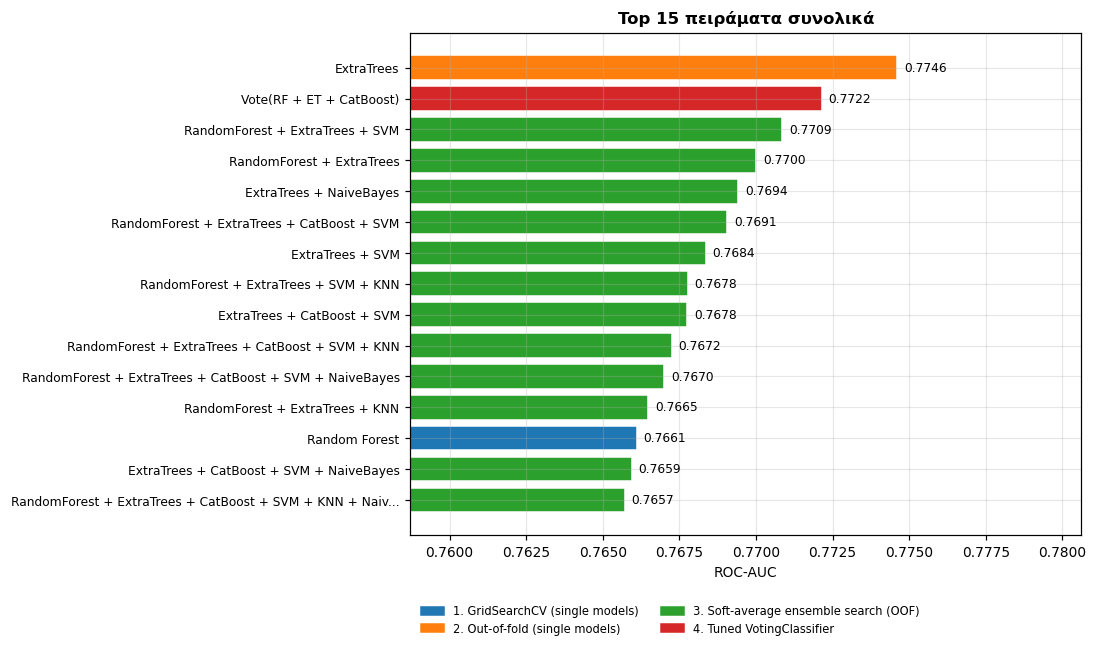

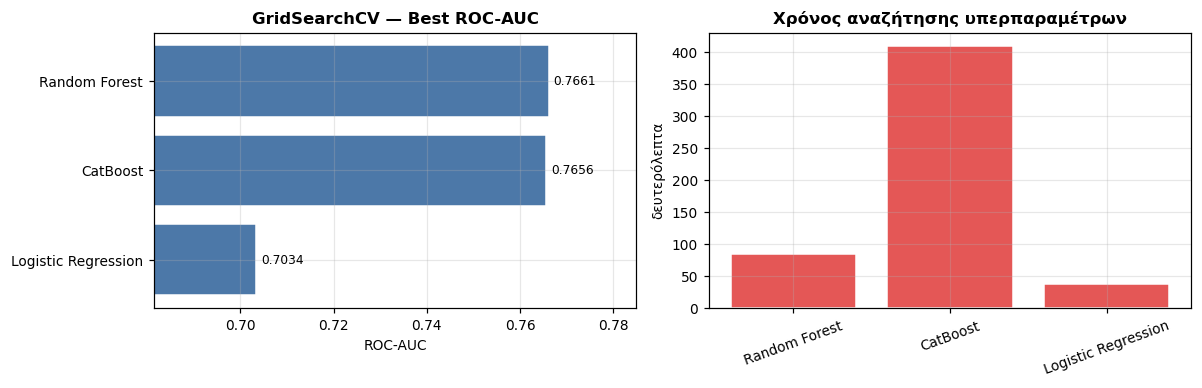

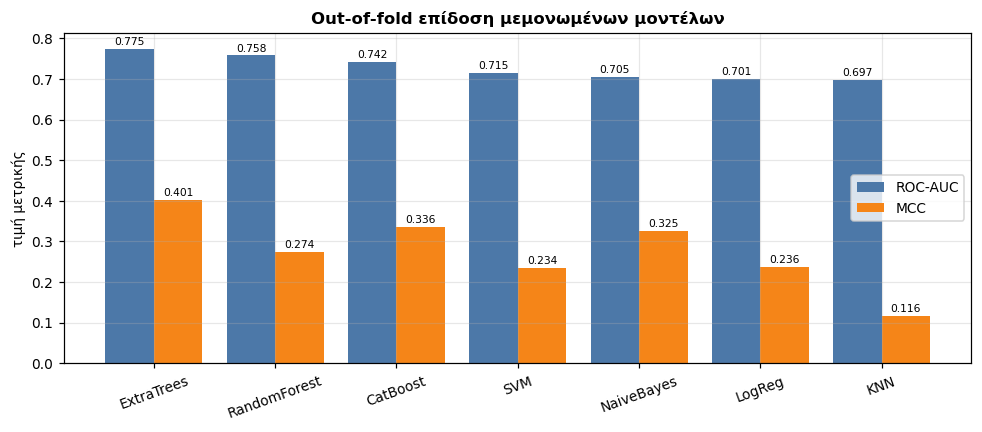

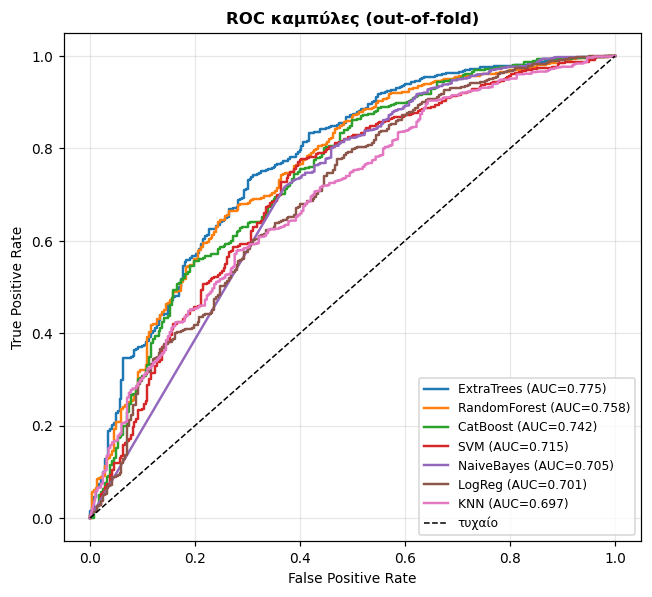

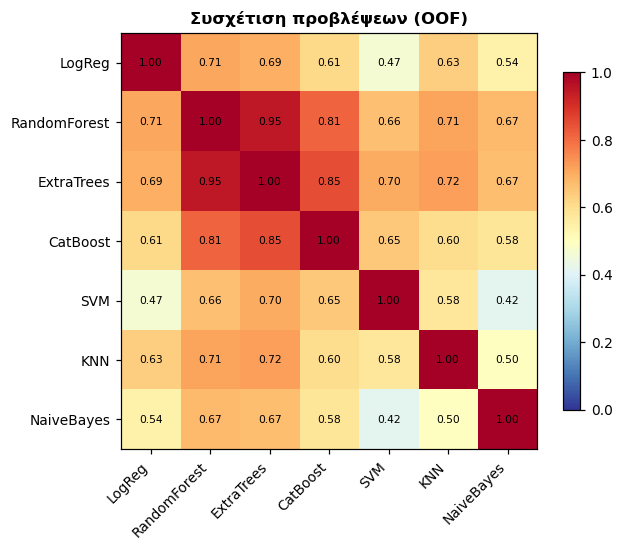

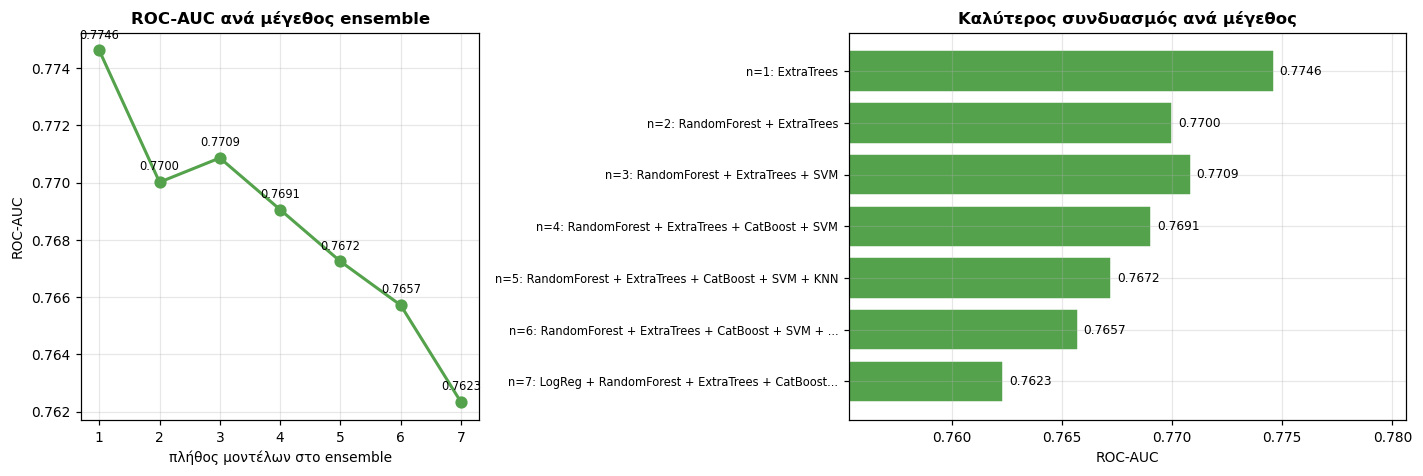

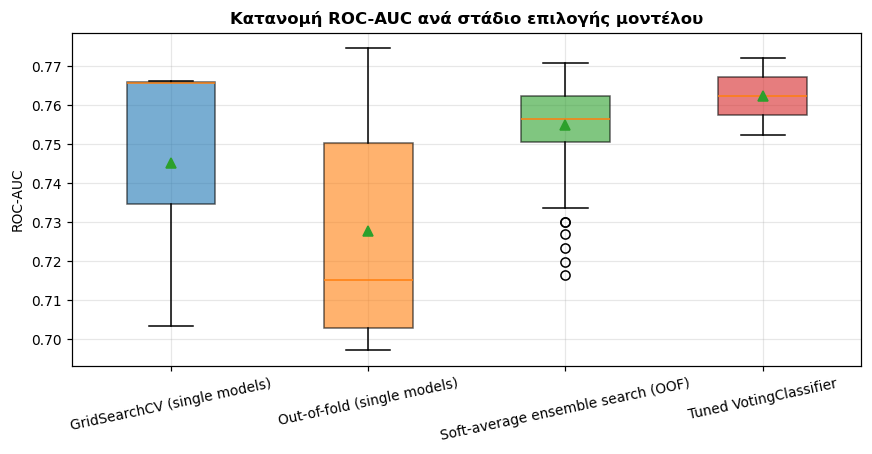


=== Αποθηκευμένα διαγράμματα ===
  c:\Users\tsian\OneDrive\Υπολογιστής\MSc_Thesis\results\Label_cutoff_20%\Hyperparameter_tunning_mi_catboost\model_plot_comparison_overall_top15.png
  c:\Users\tsian\OneDrive\Υπολογιστής\MSc_Thesis\results\Label_cutoff_20%\Hyperparameter_tunning_mi_catboost\model_plot_comparison_gridsearch_single.png
  c:\Users\tsian\OneDrive\Υπολογιστής\MSc_Thesis\results\Label_cutoff_20%\Hyperparameter_tunning_mi_catboost\model_plot_comparison_oof_auc_vs_mcc.png
  c:\Users\tsian\OneDrive\Υπολογιστής\MSc_Thesis\results\Label_cutoff_20%\Hyperparameter_tunning_mi_catboost\model_plot_comparison_roc_curves.png
  c:\Users\tsian\OneDrive\Υπολογιστής\MSc_Thesis\results\Label_cutoff_20%\Hyperparameter_tunning_mi_catboost\model_plot_comparison_prediction_correlation.png
  c:\Users\tsian\OneDrive\Υπολογιστής\MSc_Thesis\results\Label_cutoff_20%\Hyperparameter_tunning_mi_catboost\model_plot_comparison_best_per_ensemble_size.png
  c:\Users\tsian\OneDrive\Υπολογιστής\MSc_Thesis\res

In [69]:
# === [ΠΡΟΣΘΗΚΗ] ΤΕΛΙΚΟΣ ΠΙΝΑΚΑΣ ΟΛΩΝ ΤΩΝ ΣΥΓΚΡΙΣΕΩΝ + ΔΙΑΓΡΑΜΜΑΤΑ ===
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

RESULTS_DIR = globals().get('RESULTS_DIR', '../results')
os.makedirs(RESULTS_DIR, exist_ok=True)

CSV_PATH  = os.path.join(RESULTS_DIR, 'pick_best_model_process.csv')
PLOT_BASE = os.path.join(RESULTS_DIR, 'model_plot_comparison')

if not EXPERIMENTS:
    raise RuntimeError('Το EXPERIMENTS είναι κενό — τρέξε πρώτα τα κελιά των πειραμάτων.')

# ---------------------------------------------------------------- πίνακας
comparison_df = pd.DataFrame(EXPERIMENTS)
comparison_df.insert(0, 'Rank', comparison_df['ROC_AUC'].rank(ascending=False, method='min').astype(int))
comparison_df = comparison_df.sort_values(['Rank', 'Stage']).reset_index(drop=True)

comparison_df.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')
print(f'Ο πίνακας αποθηκεύτηκε: {os.path.abspath(CSV_PATH)}  ({len(comparison_df)} γραμμές)\n')

pd.set_option('display.max_colwidth', 60)
print('=== ΣΥΓΚΕΝΤΡΩΤΙΚΟΣ ΠΙΝΑΚΑΣ — Top 25 κατά ROC-AUC ===')
print(comparison_df.head(25)[['Rank', 'Stage', 'Model', 'N_models',
                              'ROC_AUC', 'MCC', 'Time_s']]
      .to_string(index=False, na_rep='-'))

print('\n=== Καλύτερο ανά στάδιο ===')
_best_stage = comparison_df.loc[comparison_df.groupby('Stage')['ROC_AUC'].idxmax()]
print(_best_stage[['Stage', 'Model', 'ROC_AUC', 'MCC', 'Time_s']]
      .sort_values('ROC_AUC', ascending=False).to_string(index=False, na_rep='-'))

_winner = comparison_df.iloc[0]
print(f"\n>>> ΝΙΚΗΤΗΣ: {_winner['Model']}  |  {_winner['Stage']}  |  ROC-AUC = {_winner['ROC_AUC']:.4f}")

try:
    from IPython.display import display
    display(comparison_df.head(25))
except Exception:
    pass

# -------------------------------------------------------------- διαγράμματα
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 9})
saved = []

def _save(fig, suffix):
    path = f'{PLOT_BASE}_{suffix}.png'
    fig.tight_layout()
    fig.savefig(path, bbox_inches='tight')
    saved.append(path)

def _barh(ax, labels, values, title, xlabel='ROC-AUC', color='#4C78A8'):
    ypos = np.arange(len(labels))
    ax.barh(ypos, values, color=color, edgecolor='white')
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    span = max(max(values) - min(values), 0.02)
    lo = max(0.0, min(values) - span * 0.35)
    hi = max(values) + span * 0.30
    ax.set_xlim(lo, hi)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight='bold')
    for i, v in enumerate(values):
        ax.text(v + (hi - lo) * 0.01, i, f'{v:.4f}', va='center', fontsize=8)

# 1) Συνολική κατάταξη: Top 15 όλων των πειραμάτων
_top = comparison_df.nlargest(15, 'ROC_AUC')
_stages = sorted(comparison_df['Stage'].unique())
_cmap = dict(zip(_stages, plt.cm.tab10.colors))
fig, ax = plt.subplots(figsize=(10, 6))
_barh(ax, [m if len(m) <= 58 else m[:55] + '...' for m in _top['Model']],
      _top['ROC_AUC'].tolist(), 'Top 15 πειράματα συνολικά',
      color=[_cmap[s] for s in _top['Stage']])
ax.tick_params(axis='y', labelsize=8)
ax.legend(handles=[Patch(color=_cmap[s], label=s) for s in _stages],
          fontsize=7.5, loc='upper left', bbox_to_anchor=(0, -0.12), ncol=2, frameon=False)
_save(fig, 'overall_top15')

# 2) GridSearchCV μεμονωμένων μοντέλων
_g = comparison_df[comparison_df['Stage'].str.startswith('1.')].sort_values('ROC_AUC', ascending=False)
if len(_g):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    _barh(axes[0], _g['Model'].tolist(), _g['ROC_AUC'].tolist(),
          'GridSearchCV — Best ROC-AUC')
    axes[1].bar(_g['Model'], _g['Time_s'], color='#E45756', edgecolor='white')
    axes[1].set_ylabel('δευτερόλεπτα')
    axes[1].set_title('Χρόνος αναζήτησης υπερπαραμέτρων', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=20)
    _save(fig, 'gridsearch_single')

# 3) Out-of-fold μεμονωμένα: ROC-AUC vs MCC
_o = comparison_df[comparison_df['Stage'].str.startswith('2.')].sort_values('ROC_AUC', ascending=False)
if len(_o):
    fig, ax = plt.subplots(figsize=(9, 4))
    xpos = np.arange(len(_o))
    ax.bar(xpos - 0.2, _o['ROC_AUC'], width=0.4, label='ROC-AUC', color='#4C78A8')
    ax.bar(xpos + 0.2, _o['MCC'], width=0.4, label='MCC', color='#F58518')
    ax.set_xticks(xpos)
    ax.set_xticklabels(_o['Model'], rotation=20)
    ax.set_ylabel('τιμή μετρικής')
    ax.set_title('Out-of-fold επίδοση μεμονωμένων μοντέλων', fontweight='bold')
    ax.legend()
    for i, (a, m) in enumerate(zip(_o['ROC_AUC'], _o['MCC'])):
        ax.text(i - 0.2, a + 0.01, f'{a:.3f}', ha='center', fontsize=7)
        ax.text(i + 0.2, m + 0.01, f'{m:.3f}', ha='center', fontsize=7)
    _save(fig, 'oof_auc_vs_mcc')

# 4) ROC καμπύλες των OOF μοντέλων
if 'oof' in globals():
    from sklearn.metrics import roc_curve, roc_auc_score
    fig, ax = plt.subplots(figsize=(6, 5.5))
    for _name, _p in sorted(oof.items(), key=lambda kv: -roc_auc_score(y, kv[1])):
        fpr, tpr, _ = roc_curve(y, _p)
        ax.plot(fpr, tpr, lw=1.6, label=f'{_name} (AUC={roc_auc_score(y, _p):.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='τυχαίο')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC καμπύλες (out-of-fold)', fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    _save(fig, 'roc_curves')

# 5) Συσχέτιση προβλέψεων μεταξύ μοντέλων
if 'oof_df' in globals():
    _corr = oof_df.corr()
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(_corr.values, cmap='RdYlBu_r', vmin=0, vmax=1)
    ax.set_xticks(range(len(_corr)))
    ax.set_xticklabels(_corr.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(_corr)))
    ax.set_yticklabels(_corr.columns)
    for i in range(len(_corr)):
        for j in range(len(_corr)):
            ax.text(j, i, f'{_corr.values[i, j]:.2f}', ha='center', va='center', fontsize=7)
    ax.grid(False)
    ax.set_title('Συσχέτιση προβλέψεων (OOF)', fontweight='bold')
    fig.colorbar(im, ax=ax, shrink=0.8)
    _save(fig, 'prediction_correlation')

# 6) Καλύτερο ensemble ανά πλήθος μοντέλων
_e = comparison_df[comparison_df['Stage'].str.startswith(('2.', '3.'))]
if len(_e):
    _bpn = _e.loc[_e.groupby('N_models')['ROC_AUC'].idxmax()].sort_values('N_models')
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4),
                             gridspec_kw={'width_ratios': [1, 1.4]})
    axes[0].plot(_bpn['N_models'], _bpn['ROC_AUC'], 'o-', color='#54A24B', lw=2, ms=7)
    for _, r in _bpn.iterrows():
        axes[0].annotate(f"{r['ROC_AUC']:.4f}", (r['N_models'], r['ROC_AUC']),
                         textcoords='offset points', xytext=(0, 8),
                         ha='center', fontsize=7.5)
    axes[0].set_xlabel('πλήθος μοντέλων στο ensemble')
    axes[0].set_ylabel('ROC-AUC')
    axes[0].set_xticks(sorted(_bpn['N_models'].unique()))
    axes[0].set_title('ROC-AUC ανά μέγεθος ensemble', fontweight='bold')
    _lbl = [f"n={int(r['N_models'])}: " +
            (r['Model'] if len(r['Model']) <= 48 else r['Model'][:45] + '...')
            for _, r in _bpn.iterrows()]
    _barh(axes[1], _lbl, _bpn['ROC_AUC'].tolist(),
          'Καλύτερος συνδυασμός ανά μέγεθος', color='#54A24B')
    axes[1].tick_params(axis='y', labelsize=7.5)
    _save(fig, 'best_per_ensemble_size')

# 7) Κατανομή ROC-AUC ανά στάδιο
fig, ax = plt.subplots(figsize=(8, 4.2))
_data = [comparison_df.loc[comparison_df['Stage'] == s, 'ROC_AUC'].dropna().values for s in _stages]
bp = ax.boxplot(_data, patch_artist=True, showmeans=True)
ax.set_xticks(range(1, len(_stages) + 1))
ax.set_xticklabels([s.split('. ', 1)[-1] for s in _stages])
for patch, s in zip(bp['boxes'], _stages):
    patch.set_facecolor(_cmap[s])
    patch.set_alpha(0.6)
ax.set_ylabel('ROC-AUC')
ax.set_title('Κατανομή ROC-AUC ανά στάδιο επιλογής μοντέλου', fontweight='bold')
ax.tick_params(axis='x', rotation=12)
_save(fig, 'by_stage_distribution')

plt.show()

print('\n=== Αποθηκευμένα διαγράμματα ===')
for p in saved:
    print(' ', os.path.abspath(p))
